# riverWQ EDA — Predicting E. coli Contamination in NZ Rivers

## Project Introduction

This notebook covers the exploratory data analysis required before the final modelling begins. The findings and conclusions will be used for preprocessing and modelling in '02_modelling.ipyb'.

# 1. Setup & Data Loading

## 1.1 Library Import

I will import the following libraries for EDA.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 1.2 Dataset Loading 

In the following code cell, main dataset will be loaded.

In [2]:
# Load the main dataset
df = pd.read_csv('../data/riverWQ_dataset.csv')


# 2. Initial Profiling

In this section, basic knowledge of the dataset will be worked out. And the quality and potential problems of the dataset will be monitored.

## 2.1 Dataset preview

In the following code cell, the basic information and overlook of dataset will be applied.

In [3]:
# Show the shape of the dataset
print(f'Dataset shape: {df.shape}')
# Show the first 5 rows
df.head().T

Dataset shape: (396, 38)


,0,1,2,3,4
site_id,arc-00001,arc-00004,arc-00005,arc-00006,arc-00008
region,Auckland,Auckland,Auckland,Auckland,Auckland
catchment,Cascade Stream,Lucas Creek,Mahurangi River,Mahurangi River,Matakana River
latitude,-36.88889,-36.72308,-36.44847,-36.39951,-36.344941
longitude,174.522115,174.6962,174.6488,174.66004,174.711358
wfs_land_cover,Forest,Urban,Forest,Rural,Rural
wfs_altitude,upland,lowland,upland,lowland,lowland
rec_land_cover_type,Native vegetation,Urban,Exotic forest,Pasture,Pasture
mean_annual_rainfall_mm,1566,1356,1498,1498,1422
pct_cropland,0.08,0.0,0.34,0.34,0.15


## 2.2 Data types 

In this section, data types of the dataset will be shown to monitor the potential mismatch problems.

In [4]:
# Show the dtype of each column
df.dtypes

site_id                                            str
region                                             str
catchment                                          str
latitude                                       float64
longitude                                      float64
wfs_land_cover                                     str
wfs_altitude                                       str
rec_land_cover_type                                str
mean_annual_rainfall_mm                          int64
pct_cropland                                   float64
pct_forest                                     float64
pct_grassland_other_herbaceous_vegetation      float64
pct_scrub_shrubland                            float64
pct_urban_bare_lightly-vegetated_surfaces      float64
pct_cropping_horticulture                      float64
pct_exotic_forest                              float64
pct_exotic_grassland                           float64
pct_exotic_scrub_shrubland                     float64
pct_indige

**Data type observations**

All dtypes are stored properly, and no conversions are needed at this stage.

## 2.3 Missing value observation

In this section, missing values will be observed in the dataset.

In [5]:
df.isnull().sum()

site_id                                          0
region                                           0
catchment                                        0
latitude                                         0
longitude                                        0
wfs_land_cover                                   0
wfs_altitude                                     0
rec_land_cover_type                              0
mean_annual_rainfall_mm                          0
pct_cropland                                     0
pct_forest                                       0
pct_grassland_other_herbaceous_vegetation        0
pct_scrub_shrubland                              0
pct_urban_bare_lightly-vegetated_surfaces        0
pct_cropping_horticulture                        0
pct_exotic_forest                                0
pct_exotic_grassland                             0
pct_exotic_scrub_shrubland                       0
pct_indigenous_forest                            0
pct_indigenous_scrub_shrubland 

**Missing value findings**

13 columns have missing values and most of them show up in pairs('band' and 'median') apart from 'nitrate_band':

- 1. Target variables:
'ecolin_median' and 'ecoli_band' are both target variables, and each of them have 57 missing values. These rows can't be used for training or evaluation. 

- 2. Other columns:
Other columns that have missing values such as 'no3n_band' and so on represent water quality outcomes measured alongside E. coli, so they will be excluded later from modelling to avoid data leakage. Thus, no more actions are needed.

## 2.4 Duplicates

In this section, I will check whether the duplicates exist in the dataset.

In [6]:
# Count exact duplicate rows
df.duplicated().sum()

np.int64(0)

**Observations**

There are no duplicates being observed in the dataset.

## 2.5 Implausible values

In this section, numerical values will be checked through to identify any implausible values or unusual values.

In [7]:
# Summary statistics for all numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,396.0,-40.749636,3.028036,-46.515137,-43.205942,-39.794082,-38.400809,-36.344941
longitude,396.0,173.810139,2.858883,167.686111,170.999559,174.995460,175.771552,178.427553
mean_annual_rainfall_mm,396.0,1486.785354,596.707801,542.000000,1092.000000,1413.000000,1677.250000,3373.000000
pct_cropland,396.0,1.475682,4.309309,0.000000,0.060000,0.520000,0.990000,34.740000
pct_forest,396.0,30.286111,20.895960,0.000000,14.040000,32.680000,41.012500,87.260000
pct_grassland_other_herbaceous_vegetation,396.0,53.139470,23.823439,0.000000,36.140000,54.570000,77.900000,93.550000
pct_scrub_shrubland,396.0,6.752121,6.250243,0.000000,3.600000,4.830000,8.490000,52.560000
pct_urban_bare_lightly-vegetated_surfaces,396.0,6.395101,14.950721,0.000000,1.260000,2.290000,3.890000,100.000000
pct_cropping_horticulture,396.0,1.475682,4.309309,0.000000,0.060000,0.520000,0.990000,34.740000
pct_exotic_forest,396.0,9.260631,7.952776,0.000000,3.062500,7.345000,14.700000,44.330000


In [8]:
# Verify the two columns are truly identical
(df['pct_cropland'] == df['pct_cropping_horticulture']).all()

np.True_

**Observations**

No implausible or impossible values are identified across all attributes in the dataset.

While 'pct_cropland' and 'pct_cropping_horticulture' have identical summary statistics (same mean, std, min, max). And verification confirms that they contain identical values. This finding needs discussing furtherly later on.

# 3. Univariate Analysis

This section works out the distribution of each feature and both target variables. The findings in this section will inform preprocessing and modelling decisions.

Two targets variables will be conducted first, followed by numerical and categorical features.

Some attributes should be excluded from univariate analysis.

'site_id', 'catchment', 'latitude' and 'longitude'are identifiers that can be excluded. 

Other water quality attributes such as 'drp_median', 'clarity_median', 'ammoniacal_n_median', 'no3n_median', 'ton_median' and their band will be excluded of analysis here since they do not represent catchment-level characteristics. And the project aims to assess how well catchment-level data can explain E. coli contamination.


## 3.1 Target variables: 'ecoli_median' and 'ecoli_band'

The two target variables are the most important variables in this dataset. So in the following section, statistics, visualisations and analysis on each target variable will be conducted.

### 3.1.1 'ecoli_median'(Regression target)

Its distribution, tendency and shape will be examined for analysis and discussion.

**The statistics will be conducted first**

In [9]:
# Statistics for ecoli_median 
print('=== ecolin_median statistics ===')
print(df['ecoli_median'].describe())

# Skewness and kurtosis
print(f"Skewness: {df['ecoli_median'].skew():.3f}")
print(f"Kurtosis: {df['ecoli_median'].kurtosis():.3f}")

=== ecolin_median statistics ===
count     339.000000
mean      266.066667
std       399.569441
min         1.000000
25%        45.000000
50%       125.000000
75%       290.500000
max      2700.000000
Name: ecoli_median, dtype: float64
Skewness: 3.046
Kurtosis: 11.168


**Statisitcs interpretation**

Skewness is 3.046 which indicates an extreme right skew. And the kurtosis is 11.168 which means it has a long heavy tail. The maximum number also reflects this. The shape shows that most rivers have moderate E. coli while a small group produce extreme high contamination.

This distribution indicates that log transformation will be needed for modelling.

**Visualisations are below**

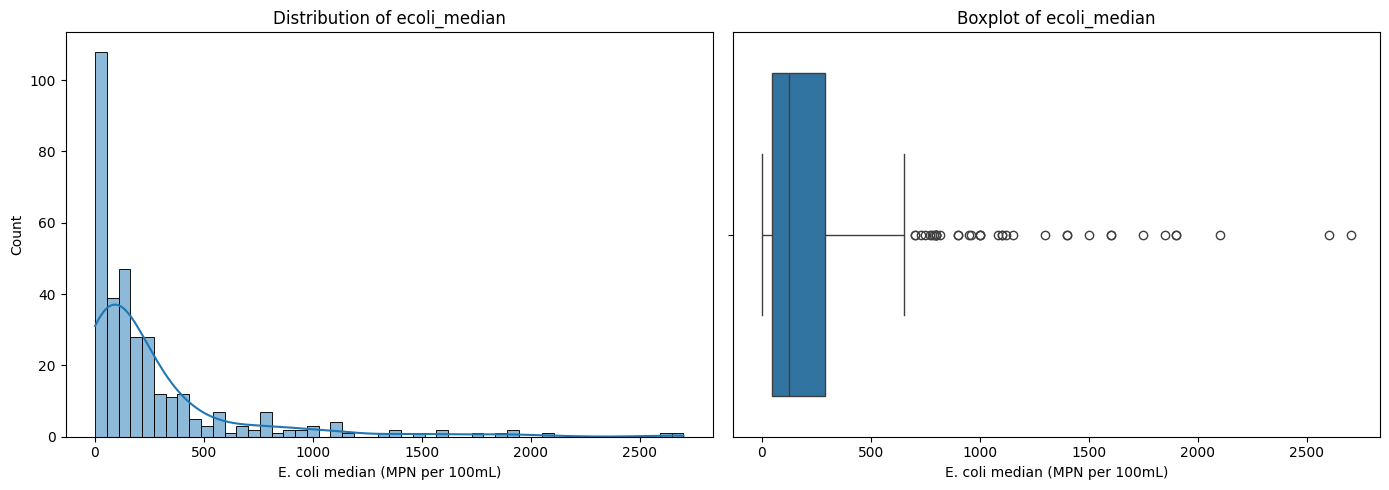

In [10]:
# Create a fig and axes
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Use seaborn to draw histplots
sns.histplot(df['ecoli_median'].dropna(), bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of ecoli_median')
axes[0].set_xlabel('E. coli median (MPN per 100mL)')
# Use seaborn to draw boxplots
sns.boxplot(x=df['ecoli_median'].dropna(), ax=axes[1])
axes[1].set_title('Boxplot of ecoli_median')
axes[1].set_xlabel('E. coli median (MPN per 100mL)')
# Save the plots itto figures
plt.tight_layout()
plt.savefig('../figures/01_ecoli_median_raw.png', bbox_inches='tight')
plt.show()

**Visualisation findings**

From the histplot, it is clear that most data clustered at low values with a long tail extedning to around 2700 MPN/100ml, which matches the finding in statistics.

Log transformation should be needed for regression and the outliers in the boxplots should be the high-contamination situation but not the data errors.

**Will try to conduct log transformation to the dataset and see how visualisation looks**

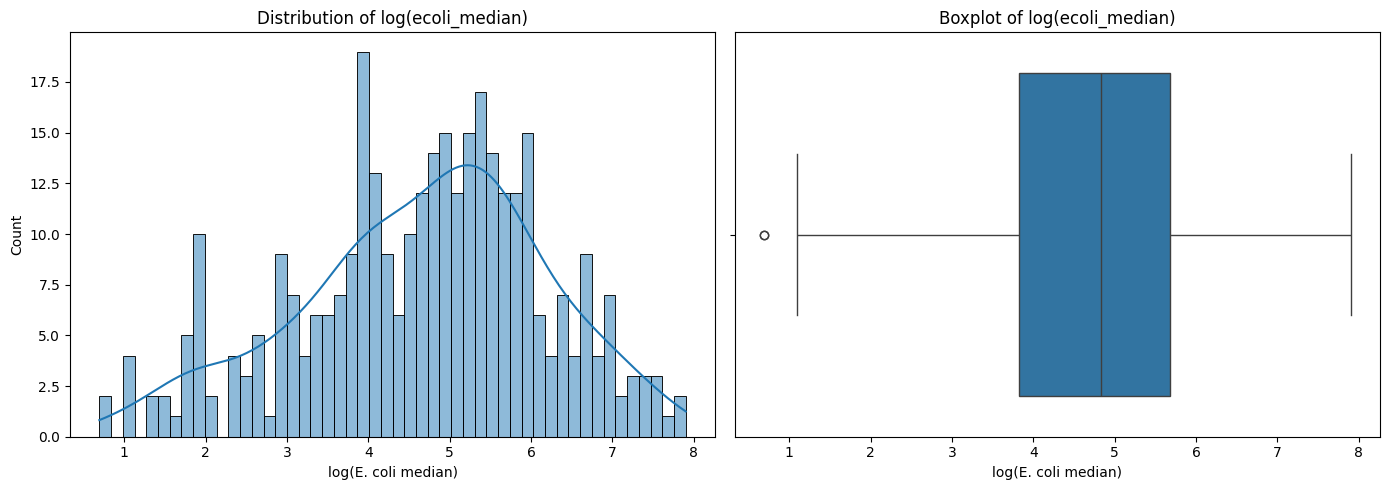

Skewness after log transformation: -0.369


In [11]:
# Temporary log transformation for visualisation only
log_ecoli = np.log1p(df['ecoli_median'].dropna())
# Create a fig and axes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Use seaborn to draw histplots
sns.histplot(log_ecoli, bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of log(ecoli_median)')
axes[0].set_xlabel('log(E. coli median)')
# Use seaborn to draw boxplots
sns.boxplot(x=log_ecoli, ax=axes[1])
axes[1].set_title('Boxplot of log(ecoli_median)')
axes[1].set_xlabel('log(E. coli median)')
# Save plots into figures
plt.tight_layout()
plt.savefig('../figures/02_ecoli_median_log.png', bbox_inches='tight')
plt.show()
# Skewness after transformation
print(f"Skewness after log transformation: {log_ecoli.skew():.3f}")

**Findings after the log transformation**

After the log transformation, the distribution is approximatel symmetric as is shown above. And skewness dropped from 3.046 to near 0. Thus, the log transformation is effective and the regression target will be modelled after log transformation.

### 3.1.2 'ecoli_band'(Classification target)

'ecoli_band' is a attribute band derived from 'ecoli_median' using fixed thresholds. The class distribution will be examined first.

**Frequency and percentage table will be calculated first**

In [12]:
# Frequency and percentage of each band
band_counts = df['ecoli_band'].value_counts().sort_index()
band_pct = df['ecoli_band'].value_counts(normalize=True).sort_index() * 100

# Combine into a clean table
band_summary = pd.DataFrame({
    'Count': band_counts,
    'Percentage': band_pct.round(1)
})
print(band_summary)

            Count  Percentage
ecoli_band                   
A              81        23.9
B              33         9.7
C              20         5.9
D             104        30.7
E             101        29.8


**A bar chart will be drawn below to show the visualisation.**

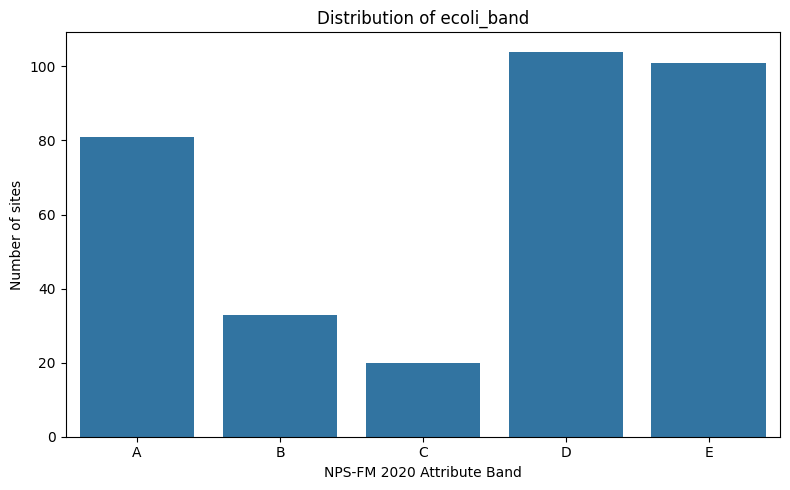

In [13]:
# Create a fig and set the size
plt.figure(figsize=(8, 5))
sns.countplot(x=df['ecoli_band'], order=['A', 'B', 'C', 'D', 'E'])

# Title and axis labels
plt.title('Distribution of ecoli_band')
plt.xlabel('NPS-FM 2020 Attribute Band')
plt.ylabel('Number of sites')

# Save figure
plt.tight_layout()
plt.savefig('../figures/03_ecoli_band_distribution.png', bbox_inches='tight')
plt.show()

**Findings**

- 1. Barchart analysis

The classification target ecoli_band is unevenly distributed across the five bands. Bands D (104) and E (101) dominate, together accounting for over half the sites, while bands B (33) and C (20) are sparsely populated. Band A has 81 sites.

This is a class imbalance issue. The minority bands (B and C) have few samples, which may make them harder for a classification model to learn and predict reliably. This will need to be considered during modelling.

- 2. Inconsistency 

The provided 'ecoli_band' does not align exactly with the NPS-FM 2020 median thresholds when applied to 'ecoli_median' alone. This is not a data error. The official NPS-FM 2020 band is determined using several criteria together, including the median, the 95th percentile, and exceedance rates over 260 and 540 MPN/100mL, whereas this dataset provides only the median. The provided band therefore reflects information beyond what ecoli_median captures. 

he provided 'ecoli_band' will be used as the classification target, as it is the official band assigned by the monitoring authority and is what this project aims to predict.

## 3.2 Numerical features

There are 17 numerical features(16 'pct_' and 'mean_annual_rainfall_mm') that will be conducted univariate analysis here. All the numerical features will firstly be scanned in one plot, then specific statistics will be computed to further analysis.

**A list will be created which contains all the numerical features with 'pct_', making it easier for the following actions and codes.

In [14]:
# Pick all columns that start with "pct_"
pct_cols = [c for c in df.columns if c.startswith('pct_')]

# Add rainfall to make the full list of numerical features
numerical_features = pct_cols + ['mean_annual_rainfall_mm']

print(numerical_features)

['pct_cropland', 'pct_forest', 'pct_grassland_other_herbaceous_vegetation', 'pct_scrub_shrubland', 'pct_urban_bare_lightly-vegetated_surfaces', 'pct_cropping_horticulture', 'pct_exotic_forest', 'pct_exotic_grassland', 'pct_exotic_scrub_shrubland', 'pct_indigenous_forest', 'pct_indigenous_scrub_shrubland', 'pct_tussock_grassland', 'pct_urban_area', 'pct_other_herbaceous_vegetation', 'pct_natural_bare_lightly-vegetated_surfaces', 'pct_artificial_bare_surfaces', 'mean_annual_rainfall_mm']


### 3.2.1 Distribution overview

A big plot showing the histogram of all 17 numerical features at once, which will provide a quick view of overall looks and shapes.

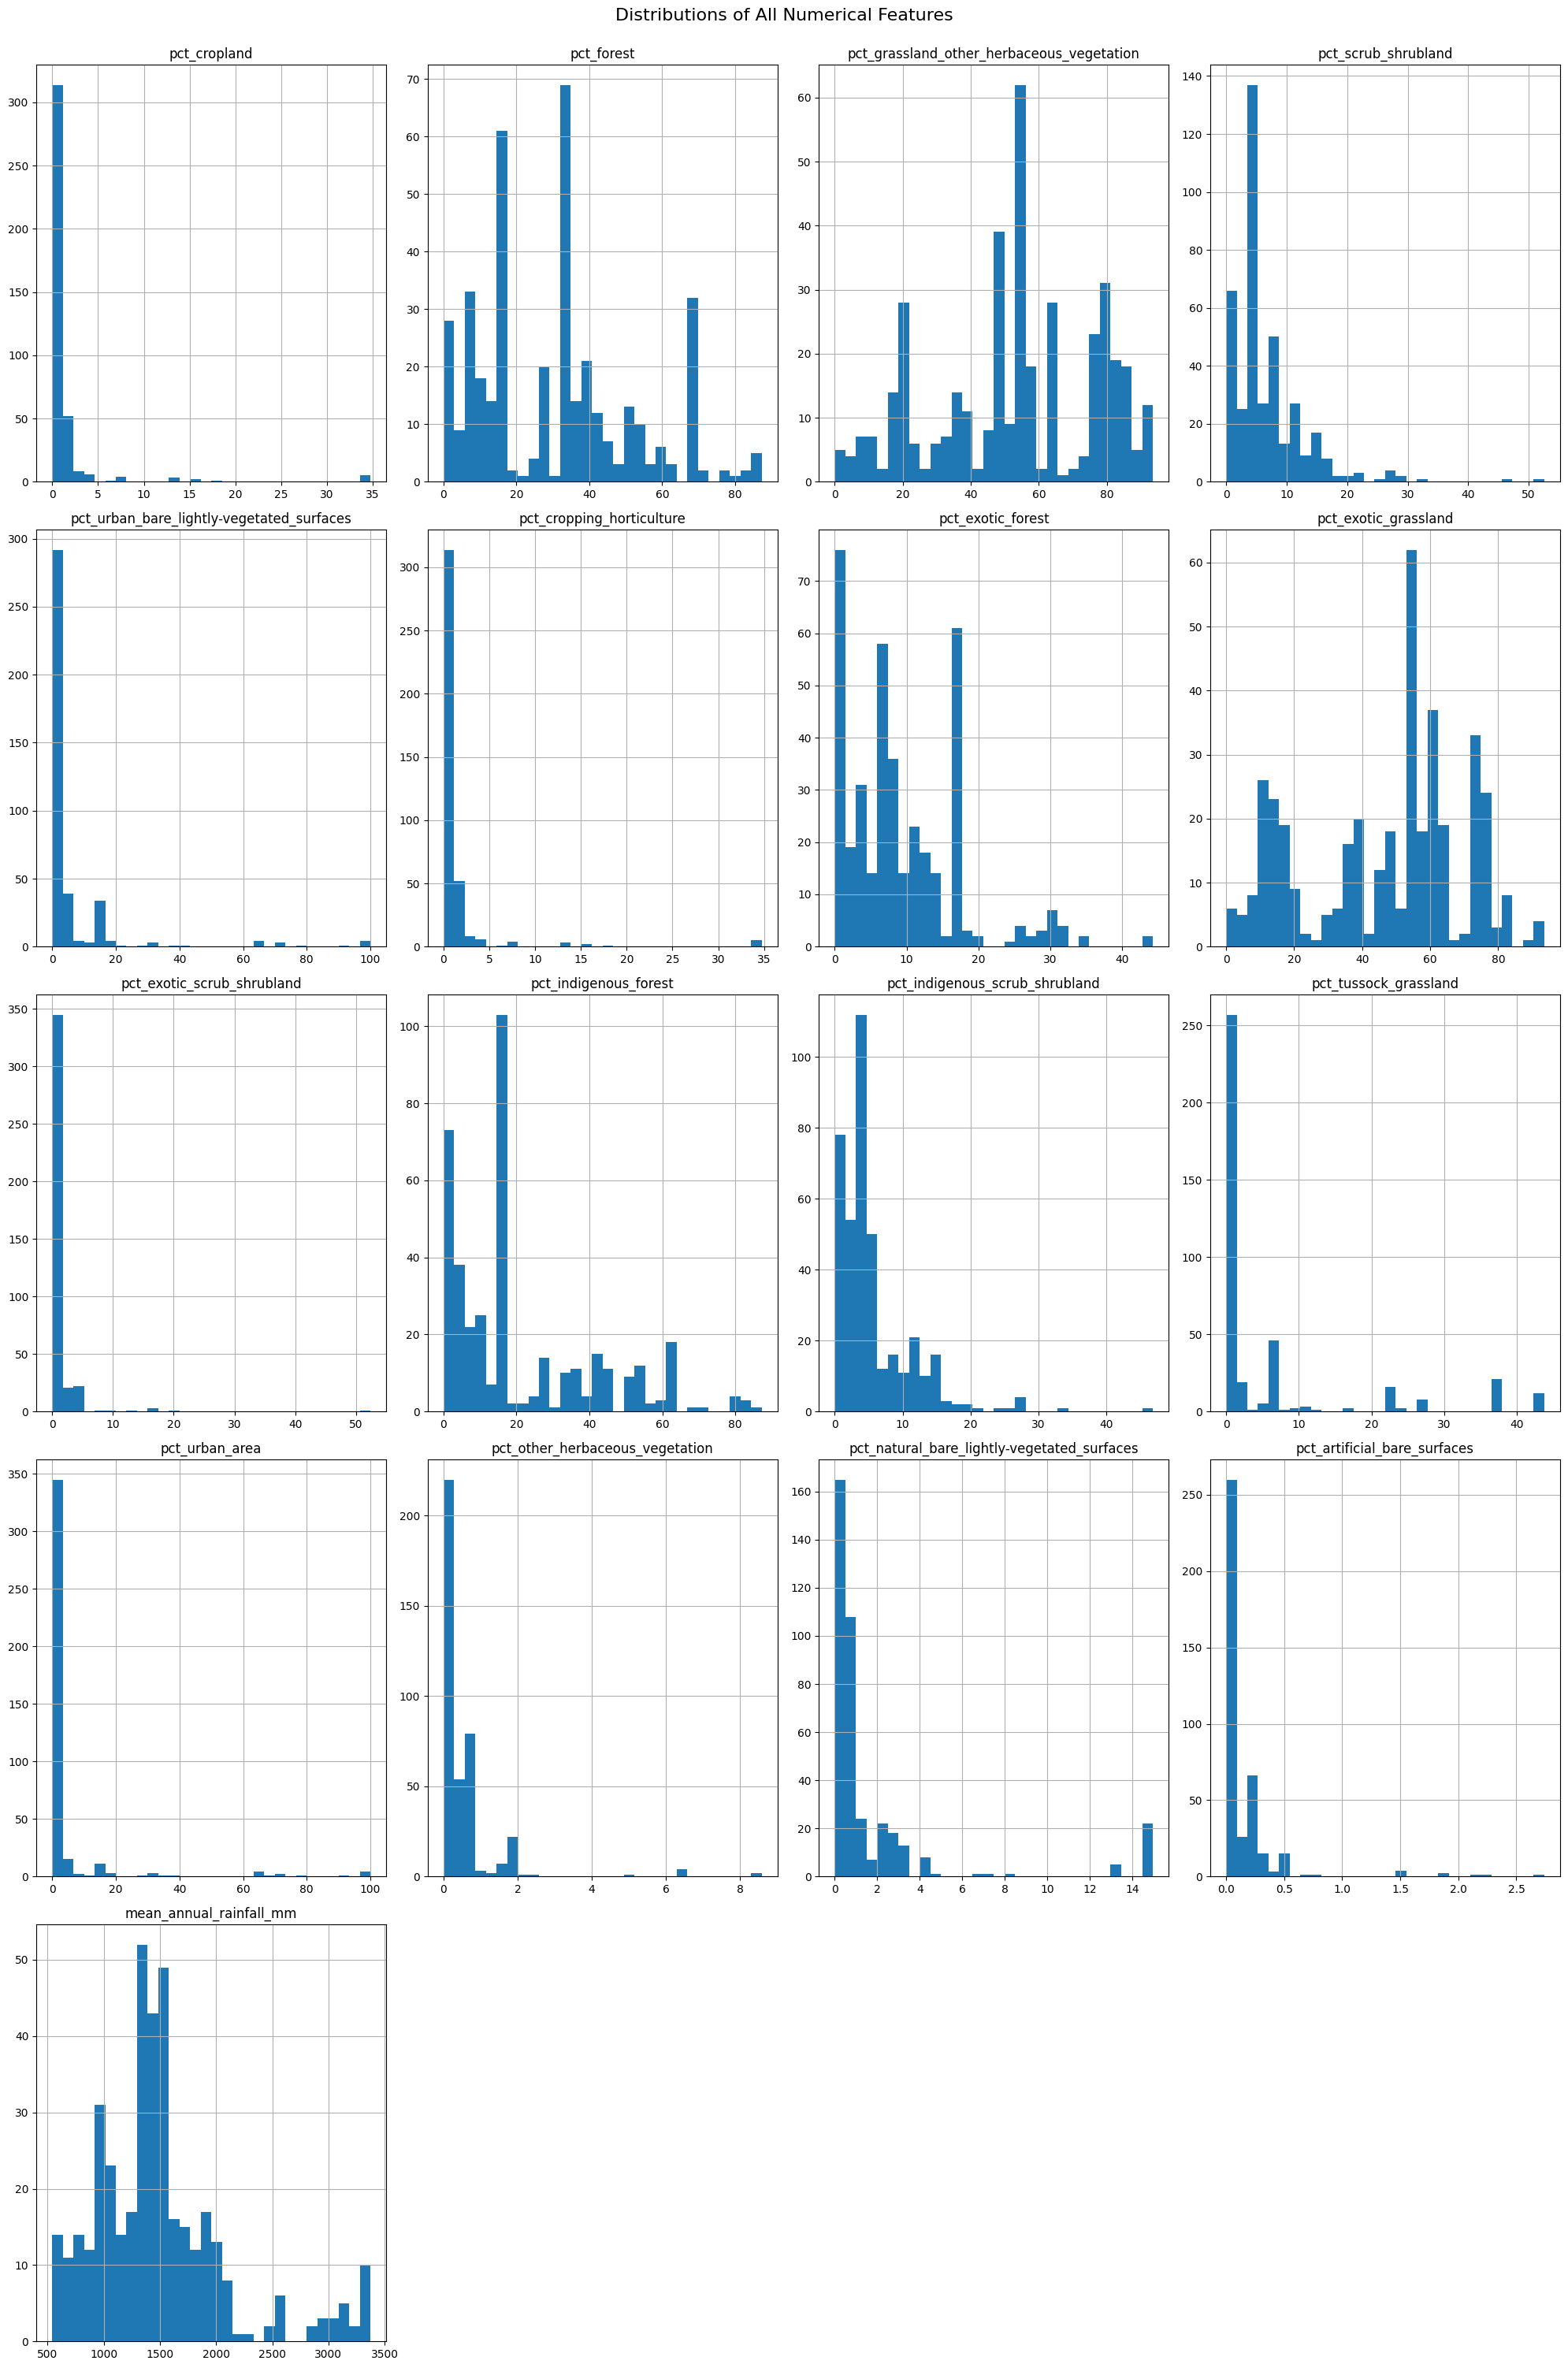

In [15]:
# Plot histograms for all 17 numerical features in one grid
df[numerical_features].hist(figsize=(20, 30), bins=30)

# Add an overall title
plt.suptitle('Distributions of All Numerical Features', fontsize=16, y=1.00)

plt.tight_layout()
plt.savefig('../figures/04_numerical_distributions_grid.png', bbox_inches='tight')
plt.show()

**Initial observations(based on the histogram)**

Over half of the 17 numerical features are right-skewed with many zeros. And a few features appear bimodal or multimodal ('pct_forest', 'pct_exotic_grassland' 'pct_grassland_other_herbaceous_vegetation', 'pct_exotic_forest') 

### 3.2.2 Statistics

To quantify the visual patterns observed in 3.2.1, I will compute two key statistics for each numerical feature: skewness (shape) and the proportion of zero values (how often the feature is absent).

In [16]:
# Calculate skewness and zero proportion for each numerical feature
skew_table = pd.DataFrame({
    'skewness': df[numerical_features].skew().round(2),
    'zero_pct': (df[numerical_features] == 0).mean().round(3) * 100
})

# Sort by skewness
skew_table = skew_table.sort_values('skewness', ascending=False)
skew_table

,skewness,zero_pct
pct_exotic_scrub_shrubland,10.84,4.3
pct_cropland,6.39,15.2
pct_cropping_horticulture,6.39,15.2
pct_other_herbaceous_vegetation,5.34,10.1
pct_artificial_bare_surfaces,5.34,18.4
pct_urban_area,4.81,5.8
pct_urban_bare_lightly-vegetated_surfaces,4.49,0.3
pct_natural_bare_lightly-vegetated_surfaces,2.95,14.4
pct_scrub_shrubland,2.75,1.3
pct_indigenous_scrub_shrubland,2.60,1.8


**Observations and implications**

- 1. Observations

Several variables show strong positive skewness, especially 'pct_exotic_scrub_shrubland', 'pct_cropland', 'pct_cropping_horticulture', 'pct_other_herbaceous_vegetation', 'pct_artificial_bare_surfaces', and 'pct_urban_area'. This means that most sites have low percentages of these land-cover types, while a small number of sites have much higher values.

The zero-value percentage shows how often a land-cover type is completely absent from a catchment. For example, 'pct_tussock_grassland', 'pct_artificial_bare_surfaces', and 'pct_cropland' have high zero percentages. These zeros are meaningful values rather than missing data, because they indicate that the land-cover type is not present in those catchments.

Some variables, such as 'pct_exotic_grassland', 'pct_grassland_other_herbaceous_vegetation', and 'pct_forest', have lower skewness and very few zero values. This suggests that these land-cover types are more commonly present across the monitoring sites.

- 2. Implications

Many pct features show strong positive skewness, but log transformation is not suitable here because log(0) is undefined and zeros are common across these columns. Tree-based models are naturally insensitive to skewness, while linear models and MLPs can handle it through standardisation. Therefore, pct features will be kept in their original form and standardised (e.g. StandardScaler) rather than log-transformed.
'mean_annual_rainfall_mm' has no zero values but operates on a very different scale to the percentage features. It will be scaled alongside the pct features.

## 3.3 Categorical features

There are 4 categorical features in the dataset which are 'region', 'wfs_land_cover', 'wfs_altitude', and 'rec_land_cover_type'. This section examines the frequency distribution of each to identify any class imbalance or rare categories.

In the following code cell, frequency and percentage table will be calculated first. And bar chart as a visualisation will be conducted.


--- region ---
                    count  percent
region                            
Otago                  97     24.5
Waikato                84     21.2
Hawke'S Bay            47     11.9
Manawatū-Whanganui     44     11.1
West Coast             31      7.8
Auckland               30      7.6
Gisborne               23      5.8
Wellington             14      3.5
Taranaki               14      3.5
Tasman                  7      1.8
Marlborough             3      0.8
Southland               2      0.5

--- wfs_land_cover ---
                count  percent
wfs_land_cover                
Rural             247     62.4
Forest            115     29.0
Urban              34      8.6

--- wfs_altitude ---
              count  percent
wfs_altitude                
lowland         239     60.4
upland          157     39.6

--- rec_land_cover_type ---
                     count  percent
rec_land_cover_type                
Pasture                252     63.6
Native vegetation      110     27.8
Urba

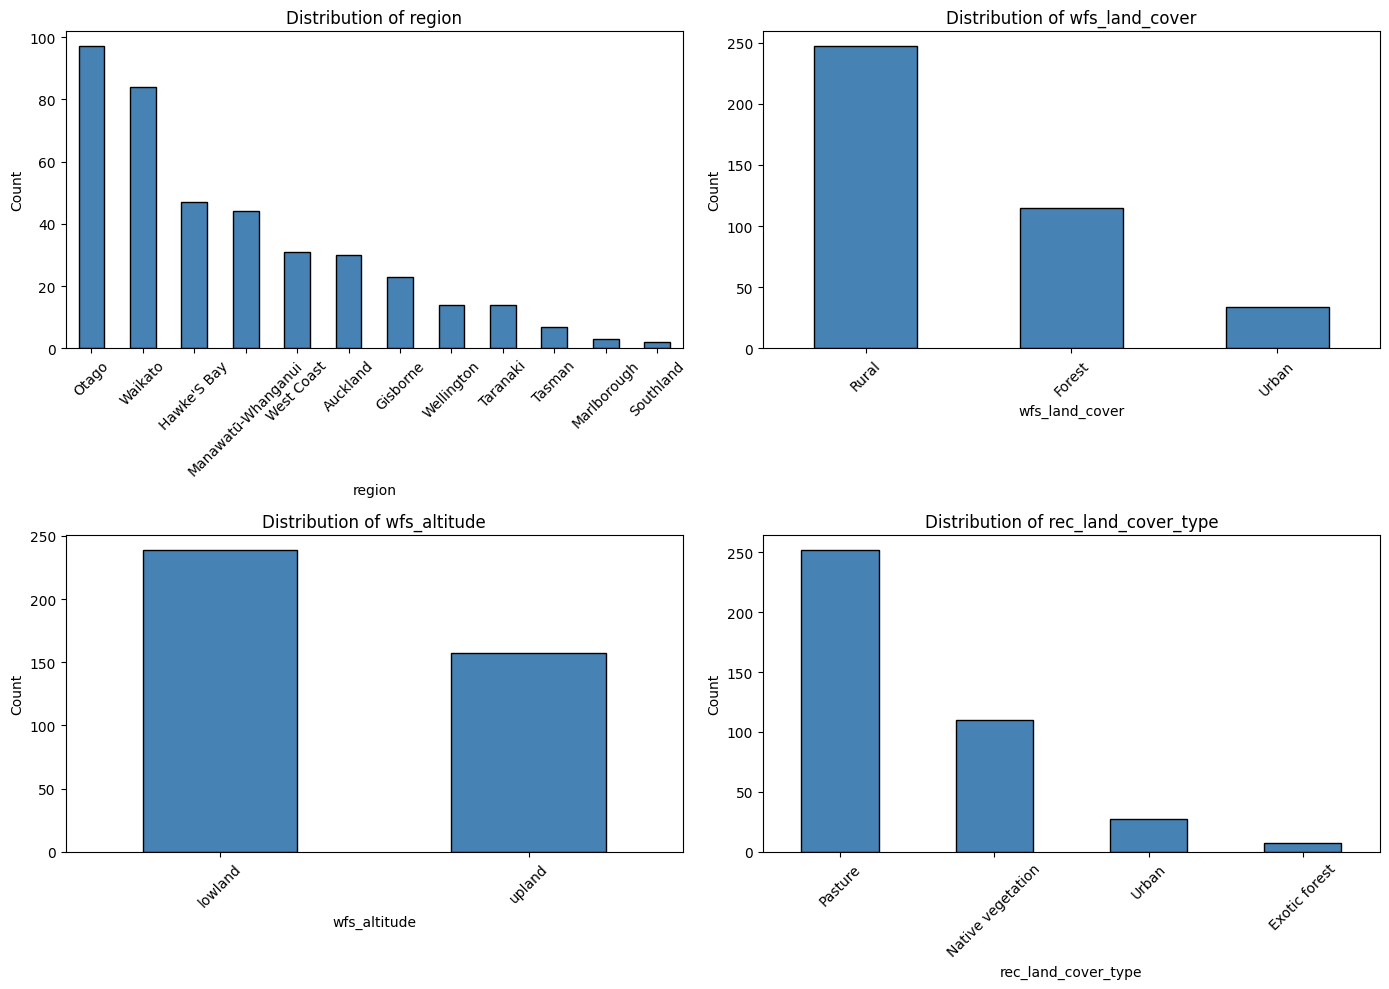

In [20]:
# Frequency and percentage of each categorical feature
cat_cols = ['region', 'wfs_land_cover', 'wfs_altitude', 'rec_land_cover_type']

for col in cat_cols:
    counts = df[col].value_counts()
    pct = (counts / len(df) * 100).round(1)
    print(f'\n--- {col} ---')
    print(pd.DataFrame({'count': counts, 'percent': pct}))

# Bar charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), cat_cols):
    df[col].value_counts().plot.bar(ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Distribution of {col}')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../figures/05_categorical_distributions.png', bbox_inches='tight')
plt.show()

**Observations**

'region' has 12 categories with a highly uneven distribution and shows class imbalance. Otago(97) and Waikato(84) account for 45% of all. While Southland(2), Marlborough(3) and Tasman(7) have very few dites. These few categories may need to be handled during encoding and modelling.

'wfs_land_cover' has three classes(Rural, Forest, Urban) with Rural being the most common.

'wfs_altitude' is a binary split.

'rec_land_cover_type' is dominated by Pasture (252), followed by Native vegetation (110). Exotic forest has only 7 sites, the imbalance is similar to the rare region.

# 4. Bivariate Analysis

This section examines the relationships between features and each target variable, as well as the relationships among features themselves. Its aim is to identify which catchment characteristics are most strongly associated with E. coli contamination and to detect multicollinearity among features. These findings will directly inform feature selection and modelling decisions.

The analysis will be organised into three parts:

- 4.1 Features and regression target(ecoli_median)

- 4.2 Features and classification target(ecoli_band)

- 4.3 Features to feature relationships

## 4.1 Features and regression target(ecoli_median)

This section examines the relationship between numerical features & categorical features and 'ecoli_median'

### 4.1.1 Numerical feature and regression target(ecoli_median)

Spearman correlation will be used here for analysis instead of Pearson because lots of them are right-skewed and non-linear.

In [24]:
# Spearman correlation between numerical features and log_ecoli_median
pct_cols = [c for c in df.columns if c.startswith('pct_')]
numerical_features = pct_cols + ['mean_annual_rainfall_mm']

corr_target = df[numerical_features + ['ecoli_median']].corr(method='spearman')['ecoli_median'].drop('ecoli_median').sort_values(ascending=False)

pd.DataFrame({'spearman_corr': corr_target.round(3)})

,spearman_corr
pct_urban_area,0.419
pct_exotic_grassland,0.192
pct_artificial_bare_surfaces,0.185
pct_exotic_forest,0.163
pct_cropland,0.028
pct_cropping_horticulture,0.028
pct_grassland_other_herbaceous_vegetation,0.011
pct_exotic_scrub_shrubland,-0.057
pct_urban_bare_lightly-vegetated_surfaces,-0.069
pct_forest,-0.070


**Observations**

'pct_urban_area' shows the strongest positive correlation (0.42) with log(ecoli_median). pct_exotic_grassland (0.19) and pct_artificial_bare_surfaces (0.19) show weaker positive associations.

The strongest negative correlations are 'pct_natural_bare_lightly-vegetated_surfaces' (-0.57) and 'pct_tussock_grassland' (-0.49). 'pct_indigenous_scrub_shrubland' (-0.32) and 'pct_scrub_shrubland' (-0.29) also show negative associations.

'mean_annual_rainfall_mm' has a weak negative correlation (-0.18). 'pct_cropland' and several other features show near-zero correlation, suggesting minimal monotonic association.

The pattern is consistent with domain knowledge: contamination rises with urban and pastoral land cover, and falls in natural or undeveloped catchments (tussock, bare surfaces, native scrub). The strongest signals come from features describing the absence of human modification rather than its presence, which suggests these land cover features will be the most useful predictors. 

However, all correlations are modest, indicating that catchment land cover alone explains only part of the variation in E. coli — as expected for environmental data.

**To examine the form of the strongest relationships, scatter plots are produced for the four features most correlated with E. coli concentration: two positive (pct_urban_area, pct_exotic_grassland) and two negative (pct_natural_bare_lightly-vegetated_surfaces, pct_tussock_grassland). The log-transformed target is used so points are not compressed at the lower end.**

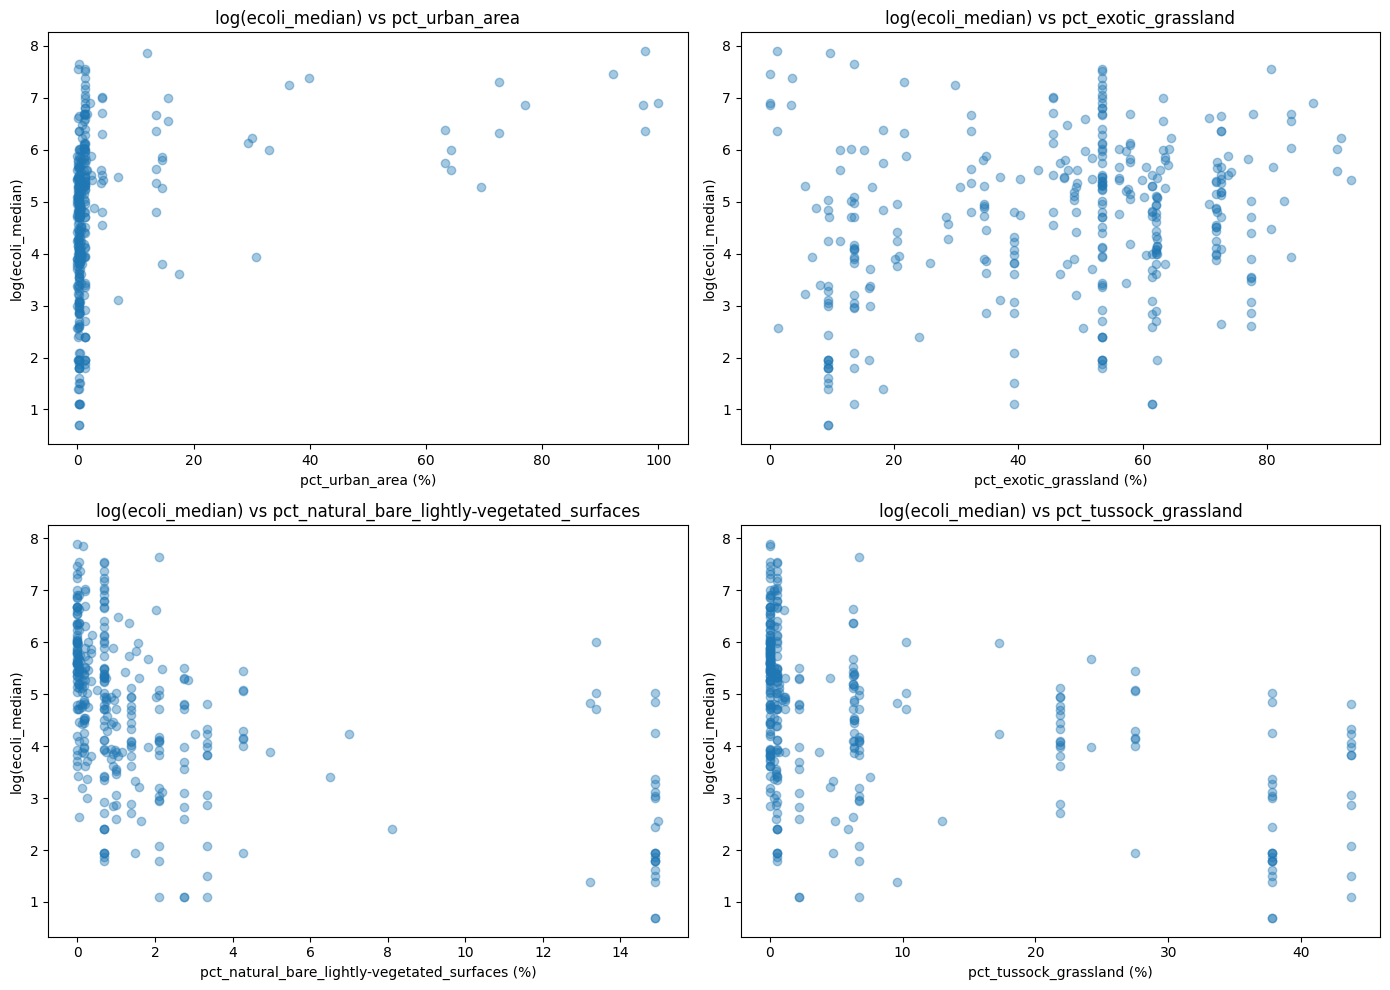

In [39]:
# Scatter plots of the four strongest-correlated features vs log(ecoli_median)
key_feats = [
    'pct_urban_area',
    'pct_exotic_grassland',
    'pct_natural_bare_lightly-vegetated_surfaces',
    'pct_tussock_grassland'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Flat the axes for loop.
for ax, feat in zip(axes.flatten(), key_feats):
    ax.scatter(df[feat], df['log_ecoli_median'], alpha=0.4)
    ax.set_xlabel(f'{feat} (%)')
    ax.set_ylabel('log(ecoli_median)')
    ax.set_title(f'log(ecoli_median) vs {feat}')

plt.tight_layout()
plt.savefig('../figures/06_scatter_key_features_ecoli.png', bbox_inches='tight')
plt.show()

**Observations**

These scatter plots confirm the correlation results. For 'pct_urban_area', sites with any urban land tend to have higher E. coli, while clean sites only appear where urban cover is near zero.

For 'pct_exotic_grassland', higher pastoral cover does not always mean high E. coli, but very low (clean) values disappear as grassland increases.

For 'pct_natural_bare_lightly-vegetated_surfaces' and 'pct_tussock_grassland', sites with more of these natural land types tend to have lower E. coli.

None of the relationships is a straight line. The patterns are noisy, which suggests non-linear models may fit this data better than a simple linear model.

### 4.1.2 Categorical feature and regression target(ecoli_median)

The relationship between categorical features and E. coli concentration is examined using boxplots of log(ecoli_median) grouped by each category. This shows whether contamination levels differ systematically across land cover types, altitude classes, and regions.

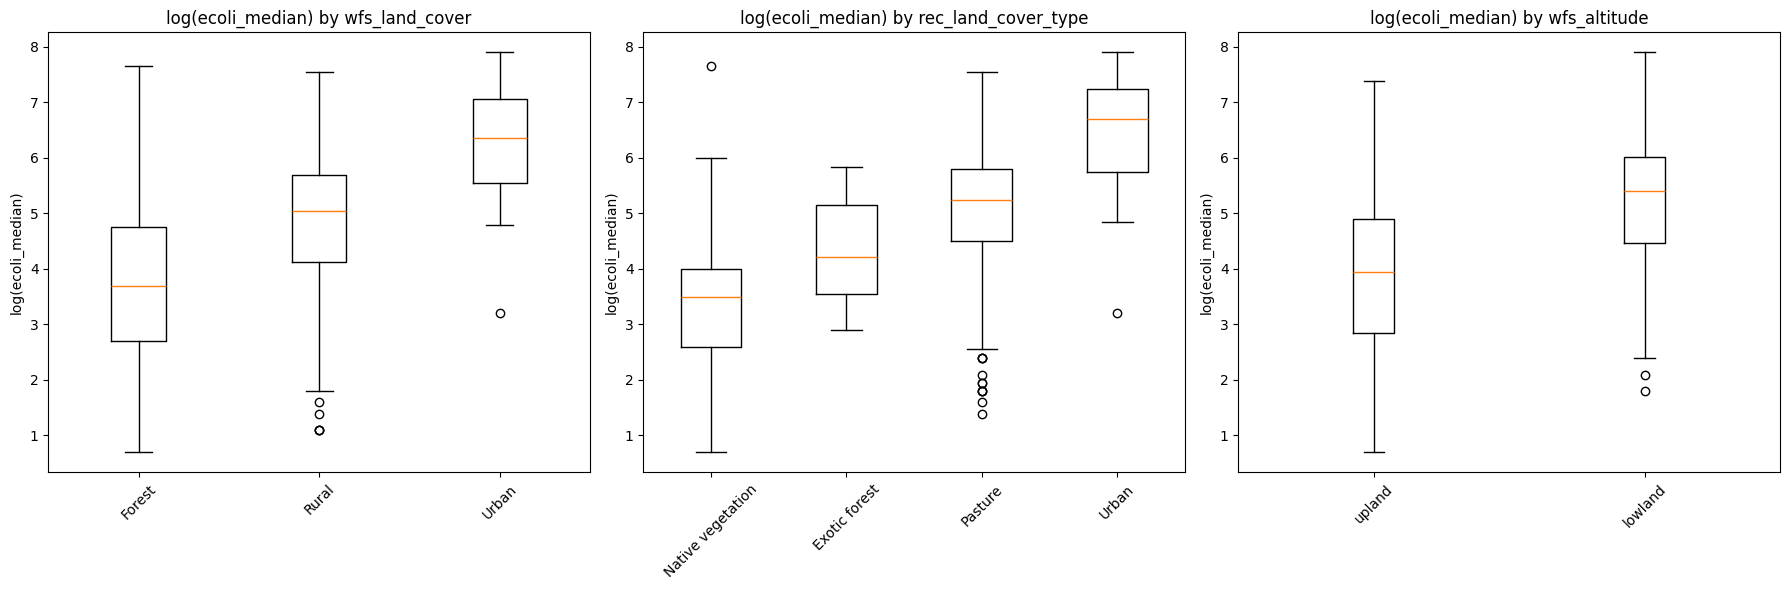

In [42]:
# Boxplots of log(ecoli_median) grouped by categorical features (apart from 'region' since it has many classes)
cat_feats = ['wfs_land_cover', 'rec_land_cover_type', 'wfs_altitude']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col in zip(axes, cat_feats):
    order = df.groupby(col)['log_ecoli_median'].median().sort_values().index
    groups = [df[df[col] == cat]['log_ecoli_median'].dropna() for cat in order]
    ax.boxplot(groups, tick_labels=order)
    ax.set_title(f'log(ecoli_median) by {col}')
    ax.set_ylabel('log(ecoli_median)')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../figures/07_boxplot_ecoli_by_categorical(apart from region).png', bbox_inches='tight')
plt.show()

**Boxplots of log(ecoli_median) grouped by 'region' will be presented below since it has many classes for better presence.

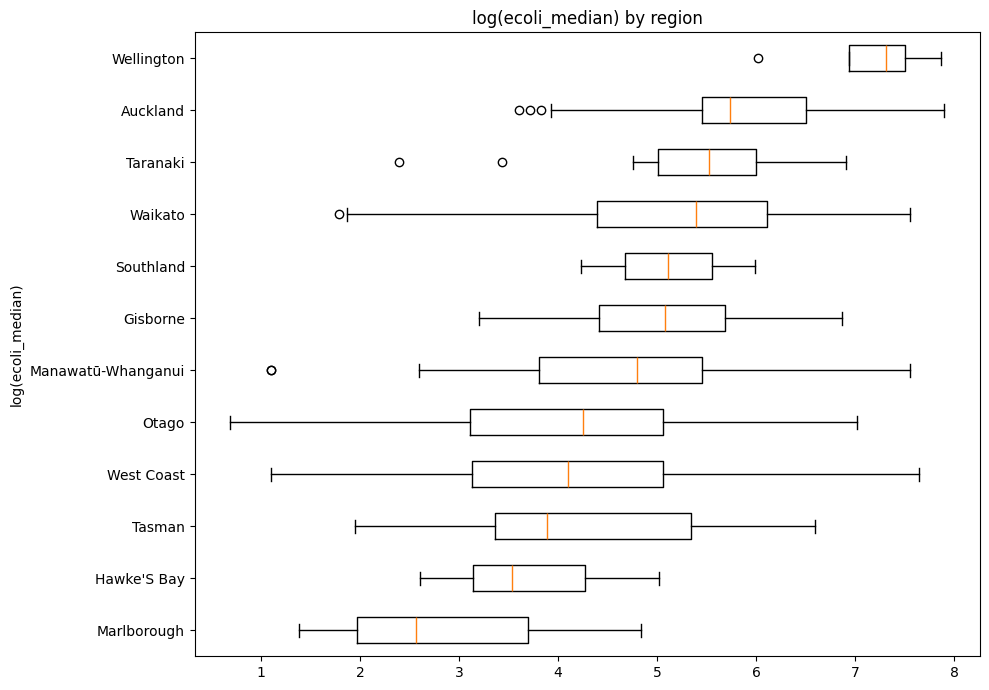

In [44]:
# Boxplots of log(ecoli_median) grouped by 'region' 
order = df.groupby('region')['log_ecoli_median'].median().sort_values().index
groups = [df[df['region'] == r]['log_ecoli_median'].dropna() for r in order]

fig,ax = plt.subplots(figsize = (10,7))
ax.boxplot(groups, tick_labels=order, vert=False)
ax.set_title(f'log(ecoli_median) by region')
ax.set_ylabel('log(ecoli_median)')

plt.tight_layout()
plt.savefig('../figures/08_boxplot_ecoli_by_region.png', bbox_inches='tight')
plt.show()